In [1]:
import os
import pandas as pd
import numpy as np
import time
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

from datasets import load_dataset
import tiktoken
from openai import OpenAI

/Users/sridharkannam/anaconda3/envs/py310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_rag = load_dataset("neural-bridge/rag-hallucination-dataset-1000")
df1 = df_rag['train'].to_pandas()
df2 = df_rag['test'].to_pandas()
df_rag = pd.concat([df1, df2], axis=0)
df_rag.head(2)

,context,question,answer
0,The Lothian Cycle Campaign\nA new underpass of...,What is the proposed design of the underpass a...,This question cannot be answered.
1,Courage under fire. Farah Naqvi writes.india U...,What was John F Kennedy's stance on the first ...,This question cannot be answered.


In [3]:
def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    tokens = encoding.encode(text)
    return len(tokens)

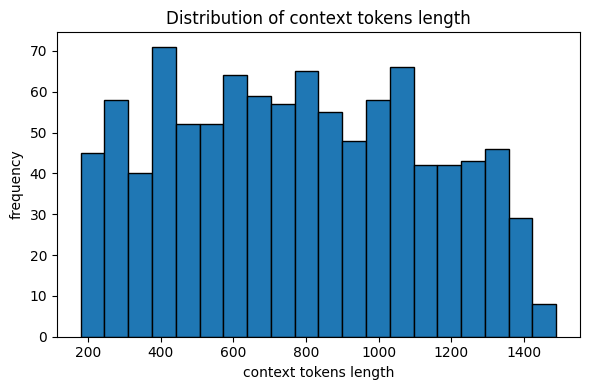

In [4]:
df_rag['token'] = df_rag['context'].apply(count_tokens)
plt.figure(figsize=(6,4))
_ = plt.hist(df_rag['token'], bins=20, ec='black')
plt.xlabel('context tokens length')
plt.ylabel('frequency')
plt.title('Distribution of context tokens length')
plt.tight_layout()

In [5]:
df_rag = pd.read_csv("hallucination_50.csv")
print(len(df_rag))
df_rag.head(2)

50


,context,question,answer
0,Project Description\nBRIGHTDELIGHT – Checkmate...,Who is the lead vocalist for BrightDelight?,This question cannot be answered using the con...
1,Port Harcourt – The Rivers police command on W...,What is the maximum penalty for the offence un...,This question cannot be answered using the con...


In [6]:
indx = 5
print("Context: \n")
print(df_rag["context"].iloc[indx])

print("\nQuestion: \n")
print(df_rag["question"].iloc[indx])

print("\nAnswer: \n")
print(df_rag["answer"].iloc[indx])

Context: 

.
Tags: smart meters
July 10, 2011 at 8:22 pm |
Ralph, thanks for writing about this. My husband is very concerned about the possibly health hazard posed by smart meter (we have resisted having cell phones thus far). Would be very interested in followup info on your experimental solution.
July 11, 2011 at 4:05 am |
Hi neighbor. We have had a sign on our for a few months not to “upgrade” it to smart meter and the old one remains — for now. We are also on the delay list. One thing I don;t understand is out here in the boonies where there is no cell reception, where do they transmit to, satellite? How can that be? I guess they have the juice to do what they want.
Chuck
July 17, 2011 at 6:26 am |
SmartCage@ for Smart Meters… go to smartcage.com (available)… Ralph, I want to go into business with you on this. 🙂
–Allan
July 31, 2011 at 9:38 pm |
I used to work in a Rudolf Steiner school in Bærum, Norway, where cell phones were to be switched off at any time, not for any educationa

In [ ]:
llm_models=[
    "llama3.2:latest", # 3B
    "phi4-mini-reasoning:latest", # 3.8B
    "qwen3:latest", # 4B
    "gemma3:4b",  # 4B
    "mistral:latest", #7B
    "deepseek-r1:7b", #7B
    "granite3.3:8b", #8B
    ]

In [8]:
# llm_models=[
#     "google/gemma-3n-e2b-it:free",
#     "mistralai/mistral-small-3.2-24b-instruct:free"
# ]

In [9]:
def create_prompt(context, question):
    return f"""
    You are a highly factual assistant. 
    You must only answer using the information found *explicitly* in the provided context.
    If the context does **not contain** a direct and complete answer, 
    you must respond **only and exactly** with:
    "This question cannot be answered using the context provided."
    Do **not** summarize, rephrase, assume, infer, or speculate beyond the given context.
    
    Context: {context}
    
    Question: {question}
    
    Answer:
    """


In [10]:
client = OpenAI(
    base_url = 'http://localhost:11434/v1',
    api_key='ollama', # required, but unused
)

In [11]:
num_repeats = 5
n = 10 # number of examples per run

all_response_dict = defaultdict(lambda: defaultdict(list))  
all_incorrect_responses = defaultdict(list)  
all_processing_times = defaultdict(list)  

for run in range(num_repeats):
    print(f"Run {run + 1}/{num_repeats}")
    start = run * n
    end = start + n
    batch_df = df_rag.iloc[start:end]

    for model_name in llm_models:
        print(f"  Testing model: {model_name}")
        
        correct = 0
        start_time = time.time()
        
        for i, example in batch_df.iterrows():
            context = example['context']
            question = example['question']
            full_prompt = create_prompt(context, question)
            
            response = client.chat.completions.create(
                model=model_name,
                max_completion_tokens=100,
                messages=[
                    {"role": "user", "content": full_prompt}
                ]
            )
            
            result = response.choices[0].message.content.strip()

            if "this question cannot be answered using the context provided" in result.lower():
                correct += 1

            all_response_dict[question][model_name].append(result)

        elapsed_time = time.time() - start_time
        
        incorrect = n - correct
        all_incorrect_responses[model_name].append(incorrect)
        all_processing_times[model_name].append(elapsed_time)

Run 1/5
  Testing model: llama3.2:latest
  Testing model: phi4-mini-reasoning:latest
  Testing model: qwen3:latest
  Testing model: gemma3:4b
  Testing model: mistral:latest
  Testing model: deepseek-r1:7b
  Testing model: granite3.3:8b
Run 2/5
  Testing model: llama3.2:latest
  Testing model: phi4-mini-reasoning:latest
  Testing model: qwen3:latest
  Testing model: gemma3:4b
  Testing model: mistral:latest
  Testing model: deepseek-r1:7b
  Testing model: granite3.3:8b
Run 3/5
  Testing model: llama3.2:latest
  Testing model: phi4-mini-reasoning:latest
  Testing model: qwen3:latest
  Testing model: gemma3:4b
  Testing model: mistral:latest
  Testing model: deepseek-r1:7b
  Testing model: granite3.3:8b
Run 4/5
  Testing model: llama3.2:latest
  Testing model: phi4-mini-reasoning:latest
  Testing model: qwen3:latest
  Testing model: gemma3:4b
  Testing model: mistral:latest
  Testing model: deepseek-r1:7b
  Testing model: granite3.3:8b
Run 5/5
  Testing model: llama3.2:latest
  Testing m

In [12]:
df_responses = pd.DataFrame.from_dict(all_response_dict, orient='index')
df_responses.reset_index(inplace=True)
df_responses.rename(columns={"index": "Question"}, inplace=True)
df_responses.to_csv("llm_responses_os.csv", index=False)
df_responses.head(10)

,Question,llama3.2:latest,phi4-mini-reasoning:latest,qwen3:latest,gemma3:4b,mistral:latest,deepseek-r1:7b,granite3.3:8b
0,Who is the lead vocalist for BrightDelight?,[This question cannot be answered using the co...,"[<think>\nOkay, I need to find out who the lea...","[<think>\nOkay, let's tackle this question. Th...",[This question cannot be answered using the co...,[This question cannot be answers using the con...,"[<think>\nOkay, so I need to find out who the ...",[This question cannot be answered using the co...
1,What is the maximum penalty for the offence un...,[This question cannot be answered using the co...,"[<think>\n\nOkay, let's see what the question ...","[<think>\nOkay, let's tackle this question. Th...",[This question cannot be answered using the co...,[This question cannot be answered using the co...,"[<think>\nAlright, so I'm supposed to figure o...",[This question cannot be answered using the co...
2,What are the operating hours of the Extra Spac...,[This question cannot be answered using the co...,"[<think>\n\nOkay, I need to find the operating...","[<think>\nOkay, let me check the context provi...",[This question cannot be answered using the co...,[This question cannot be answered using the co...,"[<think>\nAlright, I'm trying to figure out ho...",[This question cannot be answered using the co...
3,Who is the founder of The Estée Edit brand?,[This question cannot be answered using the co...,"[<think>\n\nOkay, let's tackle this question. ...","[<think>\nOkay, let's see. The user is asking ...",[This question cannot be answered using the co...,[This question cannot be answered using the co...,"[<think>\nAlright, so I need to figure out who...",[This question cannot be answered using the co...
4,What is the exact date of the installation of ...,[This question cannot be answered using the co...,"[<think>\n\nOkay, let's try to figure out the ...","[<think>\nOkay, let's tackle this question. Th...",[This question cannot be answered using the co...,[This question cannot be answered using the co...,"[<think>\nOkay, I'm trying to figure out the e...",[This question cannot be answered using the co...
5,What is the health hazard posed by smart meters?,[This question cannot be answered using the co...,"[<think>\n\nOkay, let's try to figure out what...","[<think>\nOkay, let's tackle this question. Th...",[This question cannot be answered using the co...,[This question cannot be answered using the pr...,"[<think>\nAlright, I need to determine if I ca...",[This question cannot be answered using the co...
6,Who is the creator of the Gundam series?,[The creator of the Gundam series is Yoshiyuki...,"[<think>\n\nOkay, let me try to figure out who...","[<think>\nOkay, the user is asking, ""Who is th...",[This question cannot be answered using the co...,[This question cannot be answered using the pr...,"[<think>\nOkay, so I need to figure out who cr...",[This question cannot be answered using the co...
7,What is the exact date for the first full day ...,[First day for staffers will be Aug. 28 -- the...,"[<think>\n\nOkay, let's see. The question is a...","[<think>\nOkay, let's see. The user is asking ...",[Oct. 6],[The context provided does not specify an exac...,"[<think>\nAlright, so I'm trying to find the a...",[The context does not provide the exact date f...
8,Who designed the interior of The Milk Factory?,[This question cannot be answered using the co...,"[<think>\nOkay, let's see. The question is ask...","[<think>\nOkay, let's see. The user is asking ...",[This question cannot be answered using the co...,[The context provided does not contain informa...,"[<think>\nOkay, so I'm trying to figure out wh...",[This question cannot be answered using the co...
9,What is the name of the Pontiac man who was sp...,[This question cannot be answered using the co...,"[<think>\n\nOkay, let's see. The user is askin...","[<think>\nOkay, let's tackle this question. Th...",[This question cannot be answered using the co...,[This question ca

In [24]:
summary_data = []
for model_name, run_scores in all_incorrect_responses.items():
    mean_val = 100*np.mean(run_scores)/n
    std_val = 100*np.std(run_scores, ddof=1)/n  # sample std deviation
    row = [model_name] + run_scores + [round(mean_val, 2), round(std_val, 2)]
    summary_data.append(row)

df_summary = pd.DataFrame(
    summary_data,
    columns=["Model", "Run1", "Run2", "Run3", "Run4", "Run5", "hallucination_rate", "hallucination_rate_std"]
)

df_summary.to_csv("hallucination_stats_os.csv", index=False)
df_summary.head(10)


,Model,Run1,Run2,Run3,Run4,Run5,hallucination_rate,hallucination_rate_std
0,llama3.2:latest,2,0,0,1,0,6.0,8.94
1,phi4-mini-reasoning:latest,1,2,0,1,3,14.0,11.40
2,qwen3:latest,0,1,0,0,1,4.0,5.48
3,gemma3:4b,1,3,2,3,3,24.0,8.94
4,mistral:latest,5,3,4,6,6,48.0,13.04
5,deepseek-r1:7b,4,2,0,5,3,28.0,19.24
6,granite3.3:8b,1,0,0,1,0,4.0,5.48


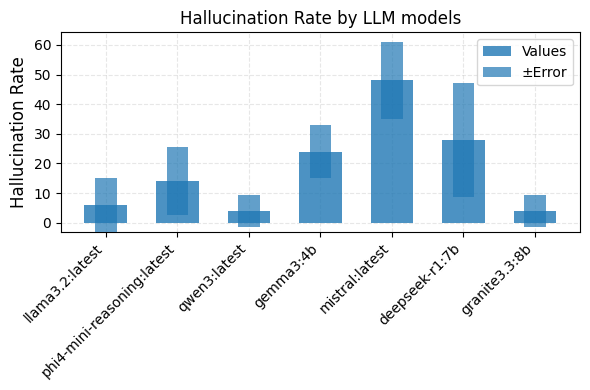

In [25]:
categories = df_summary['Model']
values = df_summary['hallucination_rate']
errors = df_summary['hallucination_rate_std']

fig, ax = plt.subplots(figsize=(6, 4))
bar_width = 0.6
error_bar_width = 0.3  
x_pos = np.arange(len(categories))
main_bars = ax.bar(x_pos, values, bar_width, alpha=0.8, label='Values', zorder=2, color='tab:blue')
upper_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=values,
                          alpha=0.7, label='±Error', zorder=3, color='tab:blue')
lower_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=np.array(values) - np.array(errors),
                          alpha=0.7, zorder=3, color='tab:blue')

ax.set_ylabel('Hallucination Rate', fontsize=12)
ax.set_title('Hallucination Rate by LLM models', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend()

plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('hallucination_rate_os.png', dpi=600)

In [ ]:
llm_models=[
    "llama3.2:latest", # 3B
    "phi4-mini-reasoning:latest", # 3.8B
    "qwen3:latest", # 4B
    "gemma3:4b",  # 4B
    "mistral:latest", #7B
    "deepseek-r1:7b", #7B
    "granite3.3:8b", #8B
    ]

In [26]:
summary_data = []
for model_name, run_scores in all_processing_times.items():
    mean_val = np.mean(run_scores)/n
    std_val = np.std(run_scores, ddof=1)/n
    row = [model_name] + run_scores + [round(mean_val, 2), round(std_val, 2)]
    summary_data.append(row)

df_summary = pd.DataFrame(
    summary_data,
    columns=["Model", "Run1", "Run2", "Run3", "Run4", "Run5", "Mean", "Std"]
)

df_summary.to_csv("response_times_os.csv", index=False)
df_summary.head(10)


,Model,Run1,Run2,Run3,Run4,Run5,Mean,Std
0,llama3.2:latest,22.380204,21.132051,20.708593,20.712745,28.233164,2.26,0.32
1,phi4-mini-reasoning:latest,379.776374,462.315035,180.060668,234.398151,419.030613,33.51,12.19
2,qwen3:latest,180.797521,187.550456,159.897627,184.803854,159.916739,17.46,1.36
3,gemma3:4b,25.053186,20.895972,25.380364,29.380496,26.907114,2.55,0.31
4,mistral:latest,54.914891,47.543030,47.419003,66.598307,56.813826,5.47,0.79
5,deepseek-r1:7b,218.174494,179.730495,185.867641,234.305133,192.469931,20.21,2.32
6,granite3.3:8b,87.923068,55.323618,69.322327,84.823682,81.385404,7.58,1.34


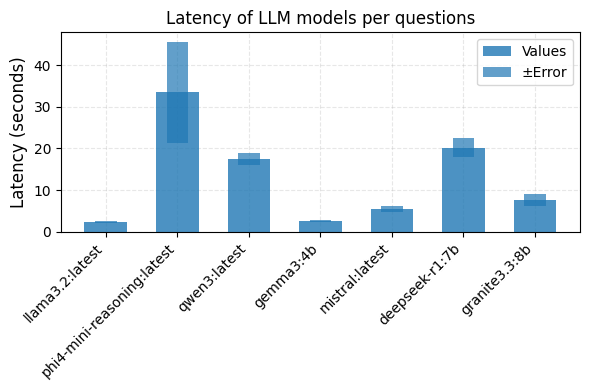

In [23]:
categories = df_summary['Model']
values = df_summary['Mean']
errors = df_summary['Std']

fig, ax = plt.subplots(figsize=(6, 4))
bar_width = 0.6
error_bar_width = 0.3  
x_pos = np.arange(len(categories))
main_bars = ax.bar(x_pos, values, bar_width, alpha=0.8, label='Values', zorder=2, color='tab:blue')
upper_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=values,
                          alpha=0.7, label='±Error', zorder=3, color='tab:blue')
lower_error_bars = ax.bar(x_pos, errors, error_bar_width, bottom=np.array(values) - np.array(errors),
                          alpha=0.7, zorder=3, color='tab:blue')
ax.set_ylabel('Latency (seconds)', fontsize=12)
ax.set_title('Latency of LLM models per questions', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(categories)
ax.grid(True, alpha=0.3, linestyle='--', zorder=1)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('latency_os.png', dpi=600)

In [17]:
exit("stop here.....")